# 02 — Agrupamento Baseline (Semana 2)

**Projeto:** Churn Prediction & Retention  
**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Semana 2:** representação, distância e baseline de agrupamento

Este notebook cobre:
- Seleção e justificativa dos atributos para agrupamento
- Pré-processamento (encoding + padronização seletiva)
- Definição da medida de distância
- Determinação empírica do K (Elbow + Silhouette)
- K-Means baseline com métricas internas
- Visualizações e análise inicial dos clusters
- Identificação de problemas do agrupamento inicial


## 1. Setup e carregamento


In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import sklearn
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
    silhouette_samples,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEAN_PATH = PROJECT_ROOT / "data" / "processed" / "telco_clean.csv"
CLUSTER_BASE_PATH = PROJECT_ROOT / "data" / "processed" / "telco_clustering_base.csv"
WITH_CLUSTERS_PATH = PROJECT_ROOT / "data" / "processed" / "telco_with_clusters.csv"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
SCALER_PATH = MODELS_DIR / "scaler.joblib"
KMEANS_PATH = MODELS_DIR / "kmeans_model.joblib"

for path in (MODELS_DIR, FIGURES_PATH, CLUSTER_BASE_PATH.parent):
    path.mkdir(parents=True, exist_ok=True)

print(f"Projeto: {PROJECT_ROOT}")
print(f"pandas={pd.__version__} | sklearn={sklearn.__version__} | scipy={scipy.__version__}")
assert CLEAN_PATH.exists(), f"Base limpa não encontrada: {CLEAN_PATH}"

df_clean = pd.read_csv(CLEAN_PATH)
print(f"Shape: {df_clean.shape}")
df_clean.dtypes


Projeto: /home/andre-luiz/personal/churn-prediction-and-retention
pandas=2.3.3 | sklearn=1.7.2 | scipy=1.15.3
Shape: (7043, 35)


customerID                  object
gender                      object
SeniorCitizen                int64
Partner                     object
Dependents                  object
tenure                       int64
PhoneService                object
MultipleLines               object
InternetService             object
OnlineSecurity              object
OnlineBackup                object
DeviceProtection            object
TechSupport                 object
StreamingTV                 object
StreamingMovies             object
Contract                    object
PaperlessBilling            object
PaymentMethod               object
MonthlyCharges             float64
TotalCharges               float64
Churn                       object
gender_label                 int64
Contract_ordinal             int64
Churn_label                  int64
Partner_binary               int64
Dependents_binary            int64
PhoneService_binary          int64
PaperlessBilling_binary      int64
MultipleLines_binary

In [2]:
df_clean.head(3)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Dependents_binary,PhoneService_binary,PaperlessBilling_binary,MultipleLines_binary,OnlineSecurity_binary,OnlineBackup_binary,DeviceProtection_binary,TechSupport_binary,StreamingTV_binary,StreamingMovies_binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,0,0,1,-1,0,1,0,0,0,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,0,1,0,0,1,0,1,0,0,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,0,1,1,0,1,1,0,0,0,0


## 2. Seleção de atributos

A clusterização será realizada sobre atributos que capturam **comportamento de uso e perfil financeiro**, conforme [`docs/dataset.md`](../docs/dataset.md).

| Atributo | Tipo | Justificativa |
|---|---|---|
| `tenure` | Numérico | Principal indicador de fidelidade; alta variância entre perfis |
| `MonthlyCharges` | Numérico | Segmenta por valor financeiro; correlacionado com churn |
| `Contract` | Ordinal | Proxy de comprometimento; contratos mensais concentram churn |
| `InternetService` | Nominal | Fibra óptica associada a maior churn (EDA Semana 1) |
| `TechSupport` | Binário/NA | Engajamento com serviços premium |
| `OnlineSecurity` | Binário/NA | Indicador de segurança digital contratada |
| `PaymentMethod` | Nominal | Sinal de automatização vs. pagamento manual |

**Atributos excluídos:**
- `TotalCharges` — derivado de `tenure × MonthlyCharges` (colinearidade)
- `customerID` — identificador sem valor analítico
- `Churn` — variável alvo; incluí-la causaria *data leakage* no agrupamento não supervisionado


In [3]:
CLUSTERING_FEATURES = [
    "tenure",
    "MonthlyCharges",
    "Contract",
    "InternetService",
    "TechSupport",
    "OnlineSecurity",
    "PaymentMethod",
]

df_cluster = df_clean[["customerID", "Churn", "Churn_label"] + CLUSTERING_FEATURES].copy()
print(f"Subconjunto para clustering: {df_cluster.shape}")
df_cluster[CLUSTERING_FEATURES].describe(include="all")


Subconjunto para clustering: (7043, 10)


,tenure,MonthlyCharges,Contract,InternetService,TechSupport,OnlineSecurity,PaymentMethod
count,7043.000000,7043.000000,7043,7043,7043,7043,7043
unique,NaN,NaN,3,3,3,3,4
top,NaN,NaN,Month-to-month,Fiber optic,No,No,Electronic check
freq,NaN,NaN,3875,3096,3473,3498,2365
mean,32.371149,64.761692,NaN,NaN,NaN,NaN,NaN
std,24.559481,30.090047,NaN,NaN,NaN,NaN,NaN
min,0.000000,18.250000,NaN,NaN,NaN,NaN,NaN
25%,9.000000,35.500000,NaN,NaN,NaN,NaN,NaN
50%,29.000000,70.350000,NaN,NaN,NaN,NaN,NaN
75%,55.000000,89.850000,NaN,NaN,NaN,NaN,NaN


### 2.1 Tratamento de outliers

No EDA (Semana 1), outliers foram identificados em `tenure` e `MonthlyCharges` via IQR, mas **não removidos** — são valores plausíveis de clientes reais (longa permanência ou planos premium), não erros de coleta.

Para o baseline K-Means, **mantemos todos os registros** e documentamos a sensibilidade do algoritmo a outliers como limitação (Seção 9).


In [4]:
def iqr_outlier_count(series: pd.Series) -> int:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

for col in ["tenure", "MonthlyCharges"]:
    n_out = iqr_outlier_count(df_cluster[col])
    print(f"{col}: {n_out} outliers IQR ({n_out / len(df_cluster):.1%} da base) — mantidos")


tenure: 0 outliers IQR (0.0% da base) — mantidos
MonthlyCharges: 0 outliers IQR (0.0% da base) — mantidos


## 3. Pré-processamento

Estratégia por tipo de variável:
- **Ordinal** (`Contract`): mapeamento 0–2
- **Binário com NA semântico** (`TechSupport`, `OnlineSecurity`): Yes=1, No=0, No internet service=-1
- **Nominal** (`InternetService`, `PaymentMethod`): One-Hot Encoding **sem** `drop_first` (clustering não sofre multicolinearidade)
- **Normalização**: `StandardScaler` **apenas** em `tenure` e `MonthlyCharges`

> **Por que não escalar binárias/ordinais?** O `StandardScaler` em colunas 0/1 ou 0/1/2 gera valores negativos sem significado semântico e distorce a contribuição dessas features na distância Euclidiana.


In [5]:
df_enc = df_cluster.copy()

contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
binary_map = {"Yes": 1, "No": 0, "No internet service": -1}

df_enc["Contract_enc"] = df_enc["Contract"].map(contract_map)
df_enc["TechSupport_enc"] = df_enc["TechSupport"].map(binary_map)
df_enc["OnlineSecurity_enc"] = df_enc["OnlineSecurity"].map(binary_map)

df_enc = pd.get_dummies(
    df_enc,
    columns=["InternetService", "PaymentMethod"],
    drop_first=False,
)

scaler = StandardScaler()
df_enc[["tenure_scaled", "MonthlyCharges_scaled"]] = scaler.fit_transform(
    df_enc[["tenure", "MonthlyCharges"]]
)

feature_cols = [
    c
    for c in df_enc.columns
    if c
    not in {
        "customerID",
        "Churn",
        "Churn_label",
        "tenure",
        "MonthlyCharges",
        "Contract",
        "InternetService",
        "TechSupport",
        "OnlineSecurity",
        "PaymentMethod",
    }
]

X = df_enc[feature_cols].values
print(f"Matriz de features: {X.shape}")
print(f"Colunas ({len(feature_cols)}): {feature_cols}")

joblib.dump(scaler, SCALER_PATH)
df_cluster.to_csv(CLUSTER_BASE_PATH, index=False)
print(f"Scaler salvo em: {SCALER_PATH}")
print(f"Base de clustering salva em: {CLUSTER_BASE_PATH}")


Matriz de features: (7043, 12)
Colunas (12): ['Contract_enc', 'TechSupport_enc', 'OnlineSecurity_enc', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'tenure_scaled', 'MonthlyCharges_scaled']
Scaler salvo em: /home/andre-luiz/personal/churn-prediction-and-retention/models/scaler.joblib
Base de clustering salva em: /home/andre-luiz/personal/churn-prediction-and-retention/data/processed/telco_clustering_base.csv


## 4. Medida de distância

**Distância escolhida: Euclidiana** (padrão do K-Means no scikit-learn).

- Mede a dissimilaridade entre dois pontos no espaço multidimensional como a raiz da soma dos quadrados das diferenças por dimensão.
- Adequada quando variáveis contínuas estão padronizadas e demais atributos estão em escala comparável.
- Interpretável e computacionalmente eficiente para ~7k registros.

**Limitação reconhecida:** variáveis nominais codificadas via OHE e binárias com valor -1 são tratadas como contínuas. Alternativas futuras (Semana 3): **Distância de Gower** ou **K-Prototypes** para dados mistos.


## 5. Determinação do K (Elbow + Silhouette)


In [6]:
K_RANGE = range(2, 13)
inertias, silhouette_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels_k))

k_df = pd.DataFrame({"k": list(K_RANGE), "inertia": inertias, "silhouette": silhouette_scores})
k_df


,k,inertia,silhouette
0,2,24814.005066,0.344470
1,3,17894.718458,0.322263
2,4,14766.261586,0.315599
3,5,12933.032116,0.317605
4,6,11260.047400,0.315935
5,7,10419.343520,0.291262
6,8,9821.017554,0.284252
7,9,9334.725331,0.283927
8,10,8965.921372,0.280782
9,11,8630.119089,0.271354


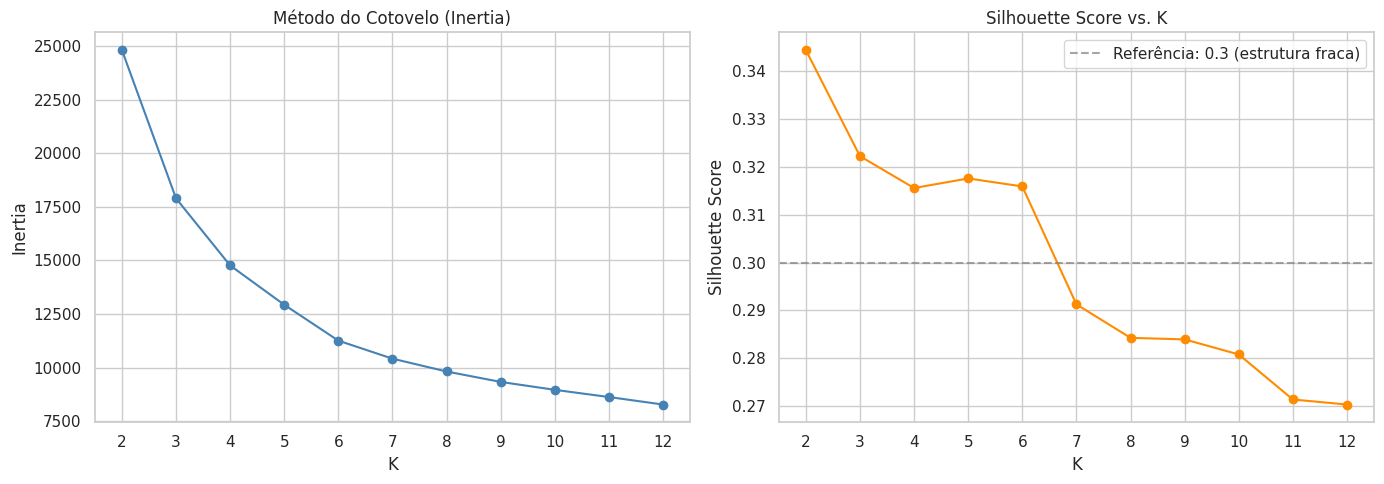

Figura salva: /home/andre-luiz/personal/churn-prediction-and-retention/reports/figures/04_elbow_silhouette.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_df["k"], k_df["inertia"], marker="o", color="steelblue")
axes[0].set_title("Método do Cotovelo (Inertia)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(k_df["k"], k_df["silhouette"], marker="o", color="darkorange")
axes[1].set_title("Silhouette Score vs. K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(K_RANGE))
axes[1].axhline(0.3, ls="--", color="gray", alpha=0.7, label="Referência: 0.3 (estrutura fraca)")
axes[1].legend()

plt.tight_layout()
elbow_path = FIGURES_PATH / "04_elbow_silhouette.png"
plt.savefig(elbow_path, bbox_inches="tight")
plt.show()
print(f"Figura salva: {elbow_path}")


In [8]:
# Decisão empírica: maior silhouette no intervalo testado
K_OPTIMAL = int(k_df.loc[k_df["silhouette"].idxmax(), "k"])
print(f"K selecionado empiricamente: {K_OPTIMAL}")
print(k_df.sort_values("silhouette", ascending=False).head(3).to_string(index=False))


K selecionado empiricamente: 2
 k      inertia  silhouette
 2 24814.005066    0.344470
 3 17894.718458    0.322263
 5 12933.032116    0.317605


## 6. K-Means baseline e métricas internas


In [9]:
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X)

sil_global = silhouette_score(X, cluster_labels)
db_index = davies_bouldin_score(X, cluster_labels)
ch_score = calinski_harabasz_score(X, cluster_labels)

metrics_df = pd.DataFrame(
    {
        "Métrica": ["Silhouette Score", "Davies-Bouldin Index", "Calinski-Harabasz Score"],
        "Valor": [sil_global, db_index, ch_score],
        "Interpretação ideal": ["Próximo de +1", "Próximo de 0", "Quanto maior, melhor"],
    }
)
metrics_df


,Métrica,Valor,Interpretação ideal
0,Silhouette Score,0.344470,Próximo de +1
1,Davies-Bouldin Index,1.146284,Próximo de 0
2,Calinski-Harabasz Score,3104.611105,"Quanto maior, melhor"


In [10]:
joblib.dump(kmeans, KMEANS_PATH)

df_result = df_clean.copy()
df_result["cluster"] = cluster_labels
df_result["clustering_algorithm"] = "kmeans"
df_result.to_csv(WITH_CLUSTERS_PATH, index=False)

print(f"Modelo salvo: {KMEANS_PATH}")
print(f"Dados com clusters: {WITH_CLUSTERS_PATH}")
print(f"Distribuição por cluster:\n{df_result['cluster'].value_counts().sort_index()}")


Modelo salvo: /home/andre-luiz/personal/churn-prediction-and-retention/models/kmeans_model.joblib
Dados com clusters: /home/andre-luiz/personal/churn-prediction-and-retention/data/processed/telco_with_clusters.csv
Distribuição por cluster:
cluster
0    5486
1    1557
Name: count, dtype: int64


## 7. Visualizações


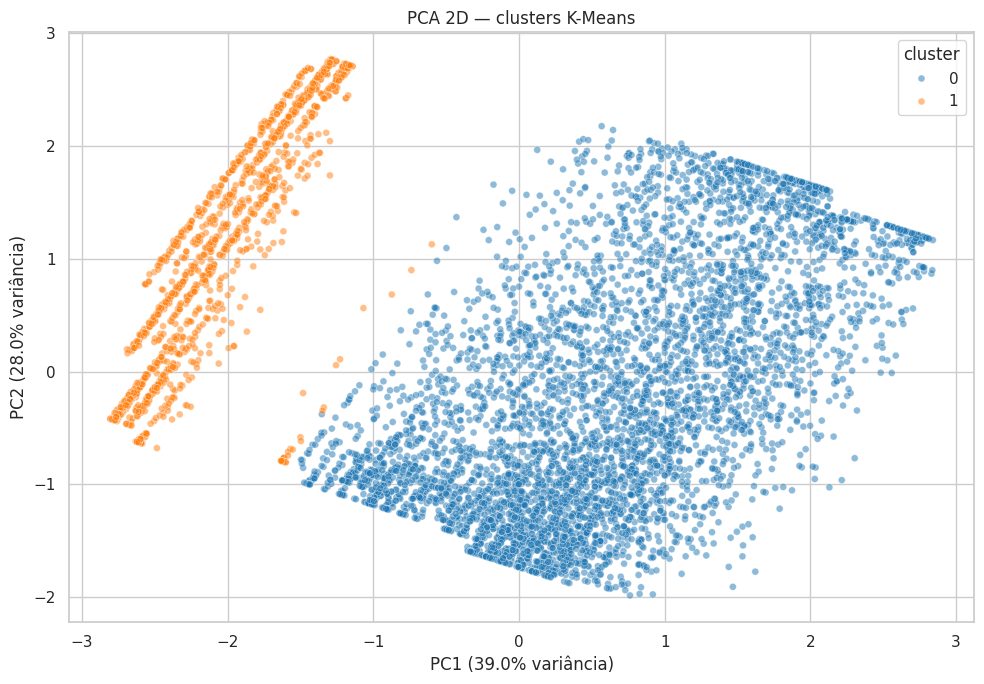

Figura salva: /home/andre-luiz/personal/churn-prediction-and-retention/reports/figures/05_pca_clusters.png


In [11]:
# 7.1 PCA 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(
    {
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "cluster": cluster_labels,
    }
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.5,
    s=25,
    ax=ax,
)
ax.set_title("PCA 2D — clusters K-Means")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variância)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variância)")
plt.tight_layout()
pca_path = FIGURES_PATH / "05_pca_clusters.png"
plt.savefig(pca_path, bbox_inches="tight")
plt.show()
print(f"Figura salva: {pca_path}")


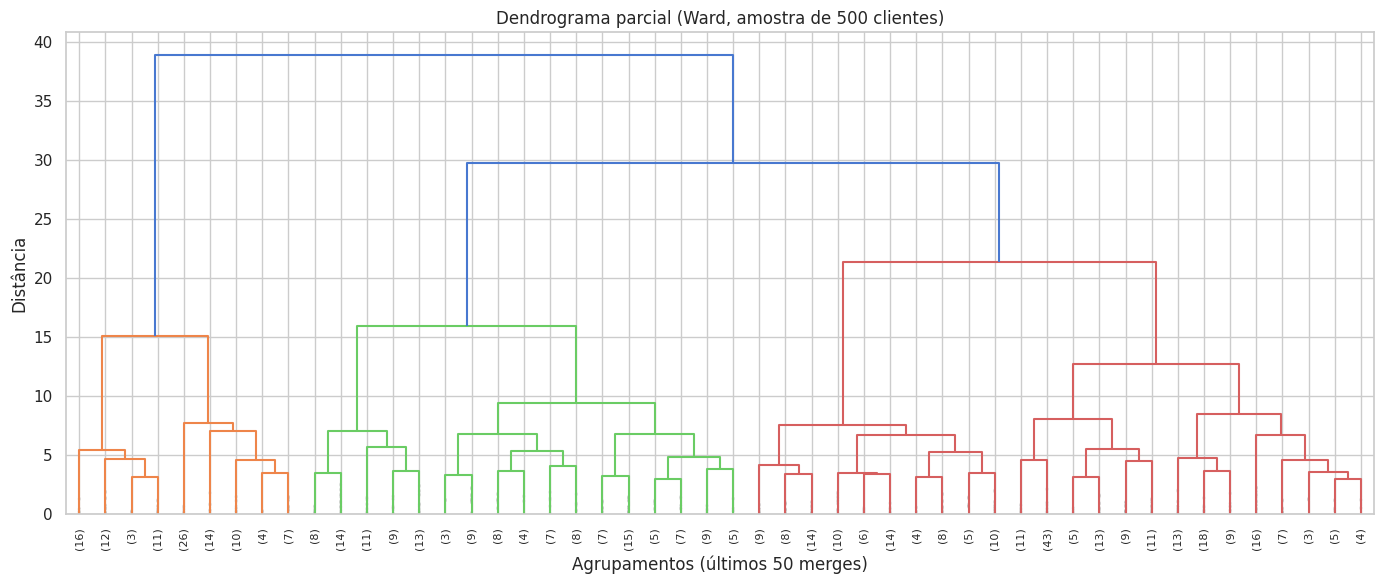

Figura salva: /home/andre-luiz/personal/churn-prediction-and-retention/reports/figures/06_dendrogram.png


In [12]:
# 7.2 Dendrograma parcial (amostra para performance)
sample_n = min(500, len(X))
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X), size=sample_n, replace=False)
X_sample = X[sample_idx]

linked = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    linked,
    truncate_mode="lastp",
    p=50,
    leaf_rotation=90.0,
    leaf_font_size=8,
    show_contracted=True,
    ax=ax,
)
ax.set_title("Dendrograma parcial (Ward, amostra de 500 clientes)")
ax.set_xlabel("Agrupamentos (últimos 50 merges)")
ax.set_ylabel("Distância")
plt.tight_layout()
dendro_path = FIGURES_PATH / "06_dendrogram.png"
plt.savefig(dendro_path, bbox_inches="tight")
plt.show()
print(f"Figura salva: {dendro_path}")


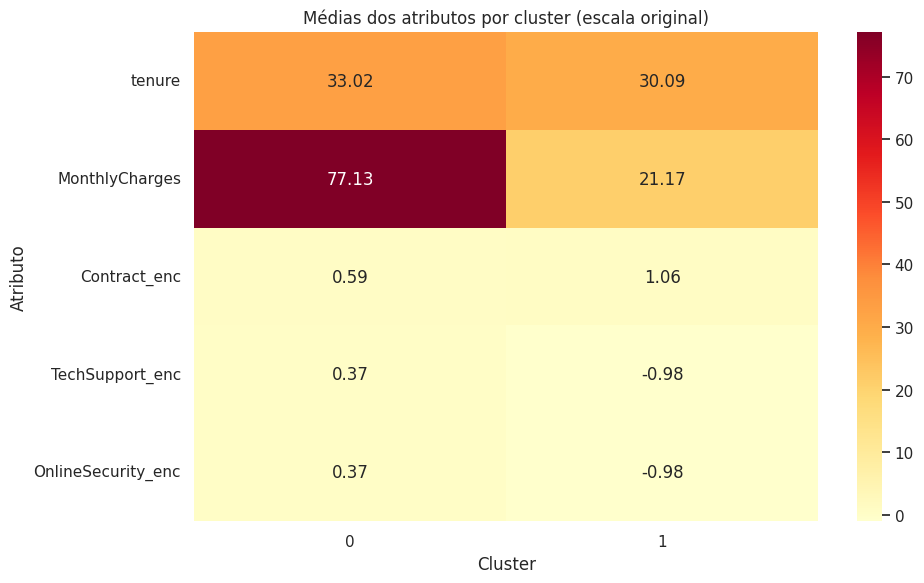

Figura salva: /home/andre-luiz/personal/churn-prediction-and-retention/reports/figures/07_centroids_heatmap.png


In [13]:
# 7.3 Heatmap de centroides (atributos originais)
profile_cols = [
    "tenure",
    "MonthlyCharges",
    "Contract_enc",
    "TechSupport_enc",
    "OnlineSecurity_enc",
]
df_profile = df_enc.copy()
df_profile["cluster"] = cluster_labels

centroids = df_profile.groupby("cluster")[profile_cols].mean().round(2)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(centroids.T, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
ax.set_title("Médias dos atributos por cluster (escala original)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Atributo")
plt.tight_layout()
heatmap_path = FIGURES_PATH / "07_centroids_heatmap.png"
plt.savefig(heatmap_path, bbox_inches="tight")
plt.show()
print(f"Figura salva: {heatmap_path}")


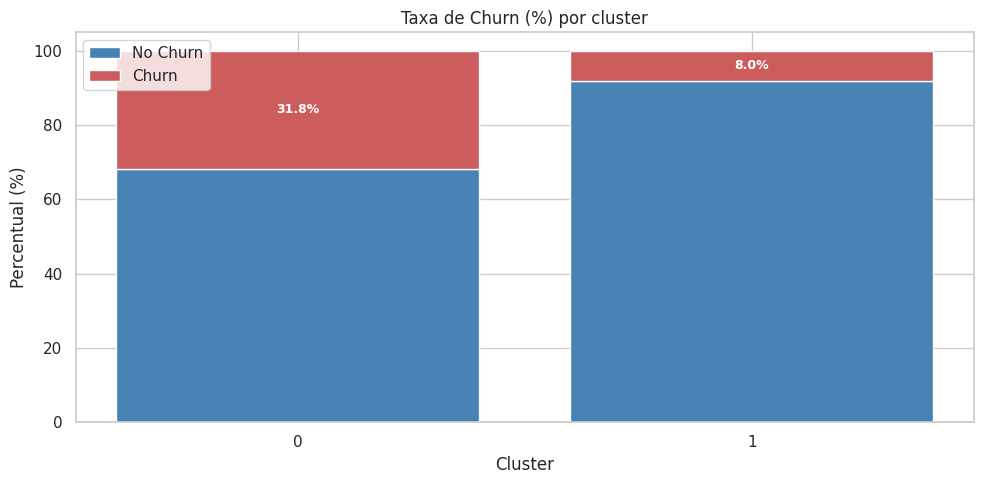

Figura salva: /home/andre-luiz/personal/churn-prediction-and-retention/reports/figures/08_churn_by_cluster.png


In [14]:
# 7.4 Distribuição de churn por cluster
churn_pct = (
    df_result.groupby("cluster")["Churn_label"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="churn_pct")
)
churn_pct["no_churn_pct"] = 100 - churn_pct["churn_pct"]

fig, ax = plt.subplots(figsize=(10, 5))
clusters = churn_pct["cluster"].astype(str)
ax.bar(clusters, churn_pct["no_churn_pct"], label="No Churn", color="steelblue")
ax.bar(
    clusters,
    churn_pct["churn_pct"],
    bottom=churn_pct["no_churn_pct"],
    label="Churn",
    color="indianred",
)
for _, row in churn_pct.iterrows():
    ax.text(
        str(int(row["cluster"])),
        row["no_churn_pct"] + row["churn_pct"] / 2,
        f"{row['churn_pct']:.1f}%",
        ha="center",
        va="center",
        color="white",
        fontsize=9,
        fontweight="bold",
    )
ax.set_title("Taxa de Churn (%) por cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Percentual (%)")
ax.legend()
plt.tight_layout()
churn_path = FIGURES_PATH / "08_churn_by_cluster.png"
plt.savefig(churn_path, bbox_inches="tight")
plt.show()
print(f"Figura salva: {churn_path}")


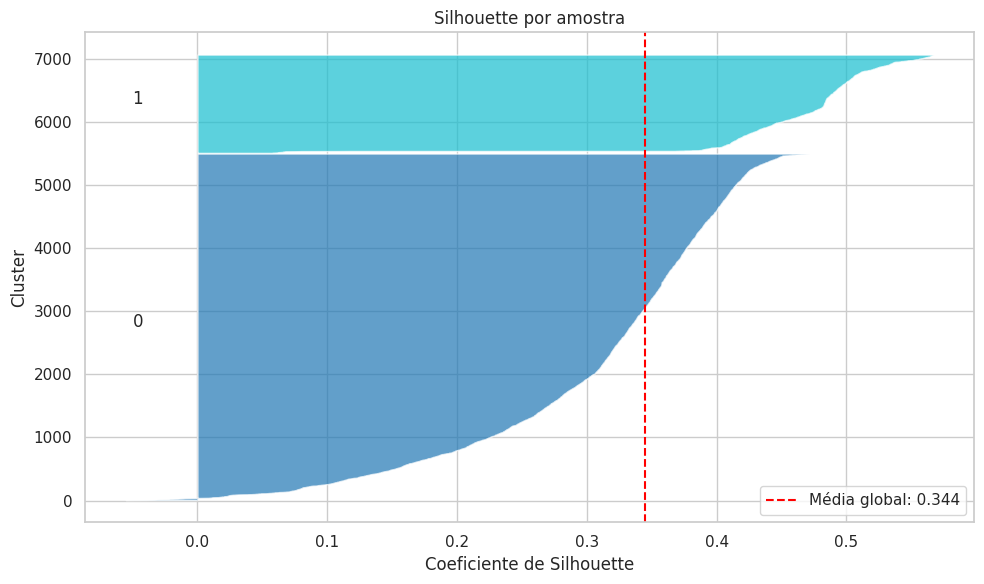

Figura salva: /home/andre-luiz/personal/churn-prediction-and-retention/reports/figures/09_silhouette_samples.png


In [15]:
# 7.5 Silhouette por amostra (diagnóstico de qualidade por cluster)
sample_sil = silhouette_samples(X, cluster_labels)

sil_df = pd.DataFrame({"cluster": cluster_labels, "silhouette": sample_sil})
sil_df = sil_df.sort_values(["cluster", "silhouette"])

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 1, K_OPTIMAL))
y_lower = 10
for i in range(K_OPTIMAL):
    ith = sil_df[sil_df["cluster"] == i]["silhouette"].values
    ith.sort()
    size = ith.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith, facecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

ax.axvline(sil_global, color="red", ls="--", label=f"Média global: {sil_global:.3f}")
ax.set_title("Silhouette por amostra")
ax.set_xlabel("Coeficiente de Silhouette")
ax.set_ylabel("Cluster")
ax.legend()
plt.tight_layout()
sil_path = FIGURES_PATH / "09_silhouette_samples.png"
plt.savefig(sil_path, bbox_inches="tight")
plt.show()
print(f"Figura salva: {sil_path}")


## 8. Análise quantitativa dos clusters


In [16]:
def dominant_contract(series: pd.Series) -> str:
    return series.value_counts().idxmax()


cluster_summary = (
    df_result.groupby("cluster")
    .agg(
        tamanho=("customerID", "count"),
        churn_pct=("Churn_label", lambda s: s.mean() * 100),
        tenure_medio=("tenure", "mean"),
        monthly_charges_medio=("MonthlyCharges", "mean"),
        contrato_dominante=("Contract", dominant_contract),
    )
    .reset_index()
)
cluster_summary["tamanho_pct"] = (cluster_summary["tamanho"] / len(df_result) * 100).round(1)
cluster_summary["churn_pct"] = cluster_summary["churn_pct"].round(1)
cluster_summary["tenure_medio"] = cluster_summary["tenure_medio"].round(1)
cluster_summary["monthly_charges_medio"] = cluster_summary["monthly_charges_medio"].round(2)

cluster_summary = cluster_summary[
    [
        "cluster",
        "tamanho",
        "tamanho_pct",
        "churn_pct",
        "tenure_medio",
        "monthly_charges_medio",
        "contrato_dominante",
    ]
]
cluster_summary


,cluster,tamanho,tamanho_pct,churn_pct,tenure_medio,monthly_charges_medio,contrato_dominante
0,0,5486,77.9,31.8,33.0,77.13,Month-to-month
1,1,1557,22.1,8.0,30.1,21.17,Two year


In [17]:
def assign_cluster_label(row: pd.Series) -> str:
    if row["tenure_medio"] >= 40 and row["monthly_charges_medio"] >= 70:
        return "Fidelizado de alto valor"
    if row["tenure_medio"] <= 12 and row["churn_pct"] >= 35:
        return "Novo em risco"
    if row["monthly_charges_medio"] <= 45 and row["churn_pct"] <= 20:
        return "Econômico estável"
    if row["churn_pct"] >= 30:
        return "Insatisfeito com serviços"
    return "Perfil intermediário"


cluster_summary["cluster_label"] = cluster_summary.apply(assign_cluster_label, axis=1)
label_map = cluster_summary.set_index("cluster")["cluster_label"].to_dict()
df_result["cluster_label"] = df_result["cluster"].map(label_map)
df_result.to_csv(WITH_CLUSTERS_PATH, index=False)

cluster_summary


,cluster,tamanho,tamanho_pct,churn_pct,tenure_medio,monthly_charges_medio,contrato_dominante,cluster_label
0,0,5486,77.9,31.8,33.0,77.13,Month-to-month,Insatisfeito com serviços
1,1,1557,22.1,8.0,30.1,21.17,Two year,Econômico estável


## 9. Problemas identificados no agrupamento inicial

Com base nas métricas, visualizações e tabela de perfis:

1. **Esfericidade assumida** — K-Means força clusters convexos; o scatter PCA tende a mostrar sobreposição entre grupos.
2. **Dados mistos** — distância Euclidiana trata OHE e codificações -1/0/1 como contínuas, o que não reflete a semântica categórica.
3. **Elbow difuso** — ausência de cotovelo claro sugere que os grupos não são naturalmente separados neste dataset.
4. **Clusters desbalanceados** — tamanhos muito desiguais reduzem a utilidade prática de segmentações menores.
5. **Sensibilidade a outliers** — K-Means é sensível a pontos extremos em `tenure` e `MonthlyCharges` (mantidos por serem plausíveis).
6. **Silhouette moderado/baixo** — valores abaixo de ~0.3 indicam estrutura de cluster fraca ou sobreposição significativa.
7. **Multicolinearidade residual** — `MonthlyCharges` correlacionado com quantidade de serviços contratados.


In [18]:
print("=== Diagnóstico automático ===")
print(f"Silhouette global: {sil_global:.3f}", "(< 0.3 = estrutura fraca)" if sil_global < 0.3 else "")
print(f"Davies-Bouldin: {db_index:.3f}", "(> 1.0 = clusters pouco separados)" if db_index > 1.0 else "")
print(f"Calinski-Harabasz: {ch_score:.1f}")
print(f"Maior cluster: {cluster_summary['tamanho_pct'].max():.1f}% da base")
print(f"Menor cluster: {cluster_summary['tamanho_pct'].min():.1f}% da base")


=== Diagnóstico automático ===
Silhouette global: 0.344 
Davies-Bouldin: 1.146 (> 1.0 = clusters pouco separados)
Calinski-Harabasz: 3104.6
Maior cluster: 77.9% da base
Menor cluster: 22.1% da base
